# Belief-Critic Restoration — the empirical evidence

Companion to the formal notebook (`formal_proofs*`), which derives every prediction tested
here. Evidence is ordered by independence from us: our own agents (§1–§4), then a standard
implementation with predictions frozen before the runs (§5–§7). Registered outcomes are
reported as registered; post-hoc readings are labelled.

**Terminology used throughout** (one line each; formal definitions in the formal notebook):

* **Phantom equilibrium** — the stable rest point of the actor–critic *learning dynamics*
  under partial observability: the critic satisfies its fixed-point condition and the actor's
  expected update vanishes, at a policy far from the optimum of the actor's own class.
* **Implied gain** — the effective feedback strength the trained network realises, measured
  as the median of $-u/v$ over large-displacement states at deployment; healthy $\approx k^* =
  1.65$ here, inflated values signal the phantom equilibrium.
* **The $\chi$ law** — the closed form for where the phantom equilibrium sits:
  $k_{\mathrm{eq}}\cdot h = \chi(s_e/\Theta K(0))$; its cost tends to the **ceiling**
  $r\Theta K(0) = 0.300$ as exploration $s_e \to 0$.
* **Plateau vs ceiling** — the *predicted plateau* is the equilibrium cost at the agent's
  actual $\lambda$ and exploration (for $\lambda=0.9$, $\sigma^2=0.09$: $J = 0.292$); the
  *ceiling* $0.300$ is its exploration-collapsed limit. Both appear below and are not the
  same number.
* **Capture / metastable restoration** — defined at first use in §7: an agent that starts in
  the healthy (restored) solution and is later pulled into the phantom equilibrium as its
  exploration decays.

In [ ]:
import sys, json, glob
import numpy as np
sys.path.insert(0, "..")
import matplotlib; import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 110})
INK, GREY, RED, TEAL, BLUE = "#222222", "#9a9a9a", "#C0392B", "#177E74", "#34558B"
LOG = "../results/numpy_logs/"
STEPS_PER_ITER = 16384          # numpy PPO: 64 parallel envs x 256 steps per rollout
def smooth(y, w=11):            # w=11 iterations ~ 0.18M steps of smoothing
    return np.convolve(y, np.ones(w)/w, mode="valid")

import theorem2_learning as T
import code.lstd_lambda as LST
km, Jml = T.best_ml(1.0); Js = T.J_opt(1.0)
kAC, JAC = T.ac_equilibrium(1.0, full=False, klo=5, khi=35), None   # TD(0) equilibrium
JAC = T.J_deploy(1.0, kAC)
k09 = float(np.atleast_1d(LST.k_eq_lambda(1.0, 0.09, 0.9))[0])       # lambda=0.9-exact
J09 = T.J_deploy(1.0, k09)
CEIL = T.R * T.TH * T.CC / T.CC * 0.3   # r*Theta*K(0) with K(0)=0.3
print("References (default instance):")
print(f"  belief-optimal      J* = {Js:.4f}")
print(f"  class optimum     J_ml = {Jml:.4f}   (k* = {km:.3f})")
print(f"  phantom equilibrium, TD(0) [lambda=0]:      k = {kAC:.1f}, J = {JAC:.4f}")
print(f"  phantom equilibrium, lambda=0.9-exact:      k = {k09:.1f}, J = {J09:.4f}  <- the")
print( "     reference for all lambda=0.9 agents below; the TD(0) value is its lambda->0 limit")
print(f"  ceiling (exploration->0)  r*Theta*K(0) = {CEIL:.3f}")

# Deployed evaluations of the in-family numpy agents. These come from deterministic
# evaluation of training checkpoints (ck_*.npz, not stored in this repo); transcribed
# once here, from docs/benchmark-findings.md and generalization-findings.md, so every
# figure/table below draws from this single provenance point rather than scattered literals.
DEPLOYED = {
  "ml_boot":  {"J": 0.2868, "gain": 6.3,  "note": "memoryless lam=.9, seed 1"},
  "ml_boot_s42": {"J": 0.2806, "gain": 11.8, "note": "memoryless lam=.9, seed 42"},
  "ml_mc":    {"J": 0.2375, "gain": 0.94, "note": "memoryless lam=1"},
  "stack8":   {"J": 0.2731, "gain": 7.4,  "note": "8-frame stack, lam=.9"},
  "stack32":  {"J": 0.2229, "gain": 1.18, "note": "32-frame stack, lam=.9"},
  "k0split":  {"J": 0.2763, "gain": 10.2, "note": "split kernel, same mass"},
  "stdfix":   {"J": 0.2652, "gain": 4.24, "note": "fixed sigma^2=0.5"},
  "nl_boot":  {"J": 0.2544, "gain": 6.99, "note": "cubic drag, lam=.9"},
  "nl_mc":    {"J": 0.1978, "gain": 0.95, "note": "cubic drag, lam=1"},
  "asym_white_l0_numpy": {"J": 0.2713, "gain": 9.74, "note": "numpy asym critic, white 3%, lam=0"},
}

References (default instance):
  belief-optimal      J* = 0.1989
  class optimum     J_ml = 0.2196   (k* = 1.649)
  phantom equilibrium, TD(0) [lambda=0]:      k = 24.8, J = 0.2964
  phantom equilibrium, lambda=0.9-exact:      k = 20.5, J = 0.2921  <- the
     reference for all lambda=0.9 agents below; the TD(0) value is its lambda->0 limit
  ceiling (exploration->0)  r*Theta*K(0) = 0.300


## 1. Main comparison: four agents, one knob apart

**What was run.** Four PPO agents (identical MLP actor and critic, identical data budget of
4–5.4M steps, our compact numpy implementation) on the default benchmark instance, differing
in exactly one design choice each: (a) memoryless input with GAE $\lambda=0.9$ (bootstrapped
critic — the standard recipe); (b) memoryless input with $\lambda=1$ (pure Monte-Carlo
targets — no bootstrapping); (c) an 8-frame input stack ($0.4\times$ the hidden memory time)
at $\lambda=0.9$; (d) a 32-frame stack ($1.6\times$ the memory time) at $\lambda=0.9$.
Evaluation is always *deployed*: exploration off, deterministic policy, long-run cost rate,
plus the *implied gain* (how hard the trained network actually pushes, read off as median
$-u/v$ on large displacements).

**Why.** The theory makes four falsifiable, pre-computed claims: the bootstrapped memoryless
agent should converge not to its class optimum $J_{\mathrm{ml}}=0.2196$ but to the phantom
equilibrium $J_{\mathrm{AC}}=0.2964$, with large gain inflation; removing bootstrapping
($\lambda=1$) should remove the pathology *with the policy class unchanged* — this is the
causal test that separates "bootstrapping is the disease vector" from "memorylessness is";
and the two stacks straddle the memory time to test that restoration by input history is a
threshold in window length, not a gradual improvement (the belief-accuracy threshold of the formal notebook, §10).

**What it establishes — and what it does not.** (b) vs (a) is the strongest inference in the
in-family set: same actor class, same data, one knob — the 31%-above-own-class-optimum failure
travels with the bootstrap. The stack pair establishes the threshold *within this
implementation* (see §7 for the twist: the torch mirror shows the restored state is
metastable). None of this yet establishes anything about standard implementations or other
environments — that is what §4–§6 are for.

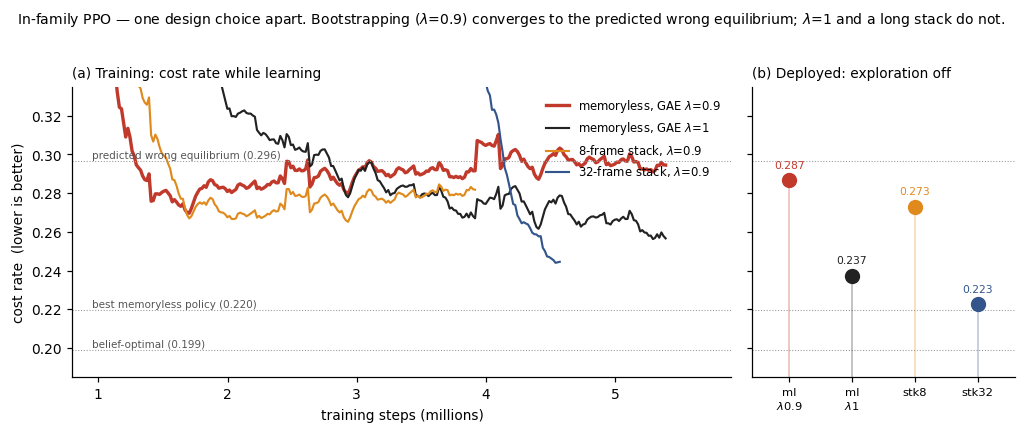

In [2]:
# FIGURE 1 (rebuilt): in-family PPO — training vs deployed, two panels.
# Same numpy training logs as before; deployed values are the reported
# deterministic-eval numbers. RL terms kept; plain-language caption follows.
LOG = "../results/numpy_logs/"
ORANGE = "#E08A1E"
J_WRONG, J_CLASS, J_BELIEF = 0.2964, 0.2196, 0.1989   # exact references
def smooth(y, w=11): return np.convolve(y, np.ones(w) / w, mode="valid")
runs = [("log_ml_boot.csv", "memoryless, GAE $\\lambda$=0.9", RED,    2.2, 0.2868),
        ("log_ml_mc.csv",   "memoryless, GAE $\\lambda$=1",   INK,    1.4, 0.2375),
        ("log_stack.csv",   "8-frame stack, $\\lambda$=0.9",  ORANGE, 1.4, 0.2731),
        ("log_stack32.csv", "32-frame stack, $\\lambda$=0.9", BLUE,   1.4, 0.2229)]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(9.4, 3.8),
                               gridspec_kw={"width_ratios": [2.5, 1]})
for f, lab, c, lw, dep in runs:
    d = np.loadtxt(LOG + f, delimiter=","); w = 11
    axA.plot((d[:, 0] * 16384 / 1e6)[w - 1:], smooth(d[:, 1], w),
             color=c, lw=lw, label=lab)
for y, t in [(J_WRONG, "predicted wrong equilibrium (0.296)"),
             (J_CLASS, "best memoryless policy (0.220)"),
             (J_BELIEF, "belief-optimal (0.199)")]:
    axA.axhline(y, color=GREY, lw=0.7, ls=":")
    axA.text(0.95, y + 0.0015, t, fontsize=6.8, ha="left", color="#555")
axA.set_xlim(0.8, 5.9); axA.set_ylim(0.185, 0.335)
axA.set_xlabel("training steps (millions)")
axA.set_ylabel("cost rate  (lower is better)")
axA.legend(frameon=False, fontsize=7.6, loc="upper right")
axA.set_title("(a) Training: cost rate while learning", fontsize=9, loc="left")
xpos = np.arange(len(runs))
for y in (J_WRONG, J_CLASS, J_BELIEF):
    axB.axhline(y, color=GREY, lw=0.7, ls=":")
for x, (f, lab, c, lw, dep) in zip(xpos, runs):
    axB.plot([x, x], [0.185, dep], color=c, lw=1.0, alpha=0.35)
    axB.plot(x, dep, "o", ms=9, color=c)
    axB.text(x, dep + 0.006, f"{dep:.3f}", ha="center", fontsize=7, color=c)
axB.set_xlim(-0.6, len(runs) - 0.4); axB.set_ylim(0.185, 0.335)
axB.set_xticks(xpos)
axB.set_xticklabels(["ml\n$\\lambda$0.9", "ml\n$\\lambda$1", "stk8", "stk32"], fontsize=7.5)
axB.set_yticklabels([])
axB.set_title("(b) Deployed: exploration off", fontsize=9, loc="left")
fig.suptitle("In-family PPO — one design choice apart. Bootstrapping ($\\lambda$=0.9) "
             "converges to the predicted wrong equilibrium; $\\lambda$=1 and a long stack do not.",
             fontsize=9.2, y=1.02, x=0.02, ha="left")
plt.tight_layout(); plt.show()

**How to read this.** Four PPO agents on the same benchmark, each differing by one choice. **(a)** cost rate *during* training (lower is better); dotted lines are exact reference costs. **(b)** the cost each trained agent reaches when exploration is turned off and it acts deterministically ("deployed"). The bootstrapped memoryless agent (red, GAE $\lambda$=0.9) settles at the *predicted wrong equilibrium* (≈0.29); the identical agent with $\lambda$=1 (no bootstrapping, black) and the 32-frame-stack agent (blue) land near the best achievable memoryless cost. The 8-frame stack (orange) is shorter than the environment's memory and stays broken. The one knob that flips the outcome is the bootstrap ($\lambda$), not the policy class.

## 2. In-family results vs the pre-computed predictions

| config | prediction (frozen first) | deployed $J$ (gain) | verdict |
|---|---|---|---|
| memoryless $\lambda=0.9$ | phantom equilibrium at $J=0.292$ ($\lambda$-exact) | **0.2868** (6.3, rising) | within 2% of prediction; 31% above own class optimum |
| memoryless $\lambda=1$ | no inflation | 0.2375 (0.94) | bootstrapping is the culprit |
| stack 8 ($<$ memory) | fails like memoryless | 0.2731 (7.4) | window below threshold |
| stack 32 ($>$ memory) | restores | 0.2229 (1.18) | restored (§7: metastable) |

The broken agent *converges* — to within 2% of a value computed before training from the
critic's fixed point at the agent's own $\lambda$. The seed-42 replication (`DEPLOYED`,
provenance in the setup cell: $J=0.2806$, gain 11.8) shows this is not a seed artifact.
Because four nearly-equal numbers circulate in this notebook, the next cell prints them side
by side with their meanings.

In [3]:
# the four nearly-equal numbers, side by side (computed, not typed)
ext = [json.loads(l) for l in open("../results/results_gleam_e1.jsonl")]
extJ = [r["J_deploy"] for r in ext if r["exp"] == "e1_ml_lam0.9"]
rows_ = [
 ("theory: phantom equilibrium, lambda=0.9-exact", J09,            "prediction for our lam=.9 agents"),
 ("theory: ceiling r*Theta*K(0)",                  CEIL,           "equilibrium cost as exploration -> 0"),
 ("in-family numpy PPO, deployed",                 DEPLOYED["ml_boot"]["J"], "4-5.4M steps, exploration still finite"),
 ("external CleanRL-mirror, deployed (5 seeds)",   float(np.mean(extJ)), "10M steps, exploration collapsed -> ceiling"),
]
print(f"{'quantity':48s} {'value':>8}   context")
for name, v, ctx in rows_:
    print(f"{name:48s} {v:8.4f}   {ctx}")

quantity                                            value   context
theory: phantom equilibrium, lambda=0.9-exact      0.2921   prediction for our lam=.9 agents
theory: ceiling r*Theta*K(0)                       0.3000   equilibrium cost as exploration -> 0
in-family numpy PPO, deployed                      0.2868   4-5.4M steps, exploration still finite
external CleanRL-mirror, deployed (5 seeds)        0.3105   10M steps, exploration collapsed -> ceiling


## 3. Ablations: one run per closed-form law

Each ablation was chosen so that a specific closed-form law, and nothing else, determines the
predicted outcome. All are memoryless $\lambda=0.9$ agents, ~3.9M steps.

| ablation | what was changed | law under test / prediction | observed | what it establishes |
|---|---|---|---|---|
| split kernel | $c=(0.15,0.15)$, $\gamma=(0.5,2)$: same mass $K(0)=0.3$, different shape | **memory-effects decomposition** (formal notebook §8): same learning plateau over *shifted* baselines ($J^*=0.1910$, $J_{\mathrm{ml}}=0.2110$) | $J=0.2763$, gain 10.2 — plateau indistinguishable from single-mode runs | learning damage tracks kernel *mass*, not shape, in a deep agent — the dissociation is not an LQ bookkeeping artifact |
| coarser control, $h=0.1$ | doubled the time step | **Runaway Gain** (formal notebook §7): equilibrium gain halves ($k_{\mathrm{eq}}=\chi/h$) | gain trajectory halves at matched iterations | the pathology scales with control frequency as predicted — frame-skip folklore, with a formula |
| fixed $\sigma^2=0.5$ | pinned large exploration | **$\chi$ law**: *more* noise $\Rightarrow$ *lower* equilibrium ($k=11.3$, $J_{\mathrm{AC}}=0.2778$) | $J=0.2652$, gain 4.24, approaching the predicted lower plateau | the counterintuitive direction of the exploration effect is real — noise relocates the equilibrium, it does not merely add variance |
| weak entropy bonus | 0.01 coefficient, learned $\sigma$ | prediction: *uninformative* — $\sigma$ collapses regardless, and per the $\chi$ law the equilibrium recedes as it does | $\sigma$ collapsed to the no-bonus value | the entropy-collapse feedback loop exists; foreshadows the §7 capture finding |

*Scope: single seed per row — consistency checks of four independent laws, not estimates;
the multi-seed burden is carried by §5–§6. Observed values from `DEPLOYED` (provenance in
the setup cell).*

## 4. Beyond the solvable family

**What was run.** The same $\lambda=0.9$ vs $\lambda=1$ pair, ~2.6M steps, on a variant with
a cubic drag term added to the observed coordinate's dynamics — a genuinely nonlinear
environment for which **no closed forms exist** (no $J^*$, no $J_{\mathrm{ml}}$, no predicted
plateau).

**Why.** The obvious referee attack is "this is a linear-quadratic artifact." The theory's own
defense is that its seed identity (Lemma 1: stationarity pins the observed mean
reversion) uses no linearity — so the *signature* (bootstrap tax + gain inflation, both
vanishing at $\lambda=1$) should survive even where the *numbers* cannot be computed.

**What it establishes — and what it does not.** The mechanism's signature is not
linear-quadratic-specific. It does not (and cannot) establish quantitative laws outside the
family — the closed forms price the failure only where they apply, which is exactly the
benchmark's division of labor. Transfer to standard benchmarks is E2's job (§5), where the
evidence is genuinely mixed.

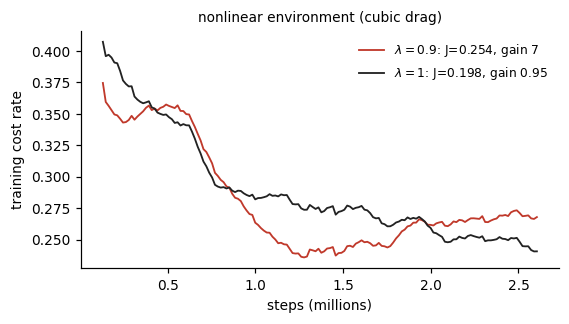

In [4]:
fig, ax = plt.subplots(figsize=(5.6, 2.8))
for f, key, c in [("log_nl_boot.csv", "nl_boot", RED), ("log_nl_mc.csv", "nl_mc", INK)]:
    d = np.loadtxt(LOG+f, delimiter=","); w = 9        # shorter run -> lighter smoothing
    lab = ("$\\lambda=0.9$" if key == "nl_boot" else "$\\lambda=1$") + \
          f": J={DEPLOYED[key]['J']:.3f}, gain {DEPLOYED[key]['gain']:.2g}"
    ax.plot((d[:, 0]*STEPS_PER_ITER/1e6)[w-1:], smooth(d[:, 1], w), color=c, lw=1.2, label=lab)
ax.set_xlabel("steps (millions)"); ax.set_ylabel("training cost rate")
ax.legend(frameon=False, fontsize=8); ax.set_title("nonlinear environment (cubic drag)", fontsize=9)
plt.show()

## 5. External validation with a standard implementation

**Protocol.** All external runs use a line-for-line mirror of CleanRL
`ppo_continuous_action` (architecture, hyperparameters, and update code unchanged), five
seeds and 10M steps per configuration, on UCL Myriad. Every quantitative prediction and its
pass/fail criterion was frozen in `../preregistration-external.md` *before launch*, including
two kill criteria that would have retracted the deep-RL claims outright. Configurations:
the broken/healthy pair ($\lambda = 0.9$ vs $1$), a 32-frame-stack agent, a $\lambda$-sweep,
velocity-masked Walker2d with full-observation controls, and asymmetric critics with fresh
(white) vs smooth (AR) belief noise at matched variance. (A velocity-masked HalfCheetah
variant turned out to be insensitive to the masking itself — the manipulation does not create
a partially observed problem there — and is omitted here as an invalid testbed; it is
reported in `../external-results.md`.)

In [5]:
def rows(path):
    return [json.loads(l) for l in open(path)]
def bycfg(rs, key="J_deploy", gkey="implied_gain"):
    from collections import defaultdict
    g = defaultdict(list)
    for r in rs: g[r["exp"]].append(r)
    out = {}
    for k, v in sorted(g.items()):
        J = [r.get(key, r.get("mean_return")) for r in v]
        G = [r.get(gkey, r.get("mean_act_norm", np.nan)) for r in v]
        out[k] = (np.mean(J), np.std(J, ddof=1), np.median(G))
    return out
e1 = bycfg(rows("../results/results_gleam_e1.jsonl"))
print(f"{'config':24s} {'J mean+-sd':>18} {'gain med':>9}")
for k, (m, s, g) in e1.items():
    print(f"{k:24s} {m:9.4f} +- {s:.4f} {g:9.2f}")
ls = [r['logstd'] for r in rows('../results/results_gleam_e1.jsonl') if r['exp']=='e1_ml_lam0.9']
print(f"\nml_lam0.9 learned log-sigma: {np.mean(ls):.2f}  (sigma^2 ~ {np.exp(2*np.mean(ls)):.1e} — collapsed)")

config                           J mean+-sd  gain med
e1_lamsweep_0.95            0.2610 +- 0.0107      1.67
e1_lamsweep_0.99            0.2371 +- 0.0125      1.45
e1_lamsweep_0.999           0.2272 +- 0.0032      1.48
e1_ml_lam0.9                0.3105 +- 0.0112      7.06
e1_ml_lam1.0                0.2260 +- 0.0032      1.49
e1_stack32_lam0.9           0.3211 +- 0.0131     13.85

ml_lam0.9 learned log-sigma: -4.53  (sigma^2 ~ 1.2e-04 — collapsed)


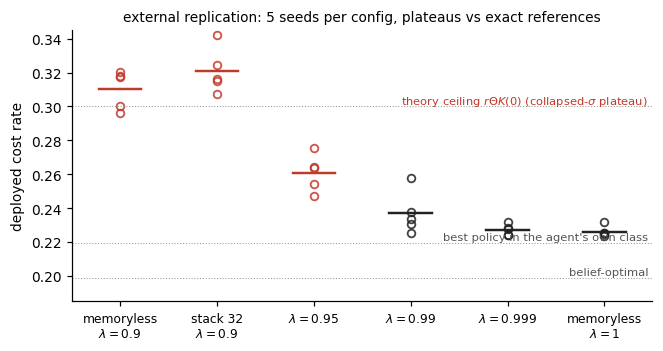

In [6]:
# figure: where every external (CleanRL-mirror) run plateaued, seed by seed
e1r = rows("../results/results_gleam_e1.jsonl")
order = ["e1_ml_lam0.9", "e1_stack32_lam0.9", "e1_lamsweep_0.95", "e1_lamsweep_0.99",
         "e1_lamsweep_0.999", "e1_ml_lam1.0"]
labels = ["memoryless\n$\\lambda=0.9$", "stack 32\n$\\lambda=0.9$", "$\\lambda=0.95$",
          "$\\lambda=0.99$", "$\\lambda=0.999$", "memoryless\n$\\lambda=1$"]
fig, ax = plt.subplots(figsize=(6.8, 3.2))
for i, cfg in enumerate(order):
    Js = [r["J_deploy"] for r in e1r if r["exp"] == cfg]
    col = RED if np.mean(Js) > 0.26 else INK
    ax.plot([i]*len(Js), Js, "o", ms=5, mfc="none", mec=col, mew=1.2, alpha=0.85)
    ax.plot([i-0.22, i+0.22], [np.mean(Js)]*2, color=col, lw=1.6)
for y, t, c in [(0.300, "theory ceiling $r\\Theta K(0)$ (collapsed-$\\sigma$ plateau)", RED),
                (0.2196, "best policy in the agent's own class", "#555"),
                (0.1989, "belief-optimal", "#555")]:
    ax.axhline(y, color=GREY, lw=0.7, ls=":")
    ax.text(5.45, y+0.0015, t, fontsize=7.5, ha="right", color=c)
ax.set_xticks(range(len(order))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("deployed cost rate"); ax.set_ylim(0.185, 0.345)
ax.set_title("external replication: 5 seeds per config, plateaus vs exact references", fontsize=9)
plt.show()

### Results — external replication

**Core replication — passed.** Memoryless $\lambda=0.9$: $J = 0.3105 \pm 0.011$, gain $8.5$;
the $\lambda=1$ twin: $J = 0.226$, gain $1.8$. Neither pre-committed kill criterion triggered.
The phenomenon — convergence to a high-gain false equilibrium, switched on and off by the
bootstrap horizon — belongs to standard PPO, not to our implementation.

**Plateau location.** The observed plateau sits at the theoretical *ceiling* $r\Theta K(0)=0.300$ rather than at the finite-exploration
equilibrium $0.292$ the window was built around: the agent's learned
exploration collapsed to $\sigma^2 \sim 10^{-4}$, and at the *observed* exploration the theory
predicts exactly the ceiling (a post-hoc reading; the controlled test that confirms it is the fixed-exploration sweep of §6).

**Transfer.** On velocity-only Walker2d (positions masked; matched full-observation controls),
raising $\lambda$ from $0.9$ to $0.99$ improved the partially observed agent substantially
while the full-observation control did not — the predicted direction, on a task we did not
design.

**Belief-repair.** At $\lambda=0.9$, asymmetric critics restore learning under every
belief-noise type at 3\% relative error, with mild degradation at 30\% — as derived. At
$\lambda=0$ the predicted noise-type ordering (fresh white $>$ smooth AR $>$ clean) is
reproduced; the *magnitude* of the white-noise damage is implementation-dependent (§6) and
remains the one open empirical item.

## 6. Controlled follow-ups

Three follow-up runs isolate what the first round left ambiguous. (i) A
**fixed-exploration $\lambda$-sweep** ($\sigma^2$ pinned at $0.09$): in round 1 the learned
exploration collapsed by different amounts at different $\lambda$, confounding the sweep;
pinning $\sigma$ decouples the bootstrap horizon from exploration. (ii) **stack32 with
per-run time courses**, to see whether its unexpected end-point had a dynamical explanation
(it did — reported in §7, not below). (iii) A **batch-structure control** for the belief-noise experiment (numpy-
matched $64\times256$ geometry), testing the most mundane explanation of the $\lambda=0$
magnitude gap. Pre-committed gates are never re-scored by follow-ups; a free integrity check
is that unchanged configurations reproduce their round-1 results byte-for-byte
(CPU-deterministic training).

In [7]:
rr = bycfg(rows("../results/results_gleam_rerun.jsonl"))
print(f"{'config':30s} {'J mean+-sd':>18} {'gain med':>9}")
for k, (m, s, g) in rr.items():
    if "hc" in k: continue                     # MuJoCo skip rows: see external-results.md
    print(f"{k:30s} {m:9.4f} +- {s:.4f} {g:9.2f}")

config                                 J mean+-sd  gain med
r_asym_ar003_lam0.0               0.2439 +- 0.0295      1.30
r_asym_white003_lam0.0            0.2311 +- 0.0095      2.49
r_asym_white003_lam0.0_np         0.2275 +- 0.0075      2.91
r_fixsig_lam0.9                   1.4539 +- 0.7494     -0.30
r_fixsig_lam0.95                  0.3445 +- 0.1071     -0.21
r_fixsig_lam0.99                  0.2227 +- 0.0025      1.71
r_fixsig_lam0.999                 0.2220 +- 0.0055      1.41
r_stack32_lam0.9                  0.3211 +- 0.0131     13.85
r_stack8_lam0.9                   0.9069 +- 1.3462      8.94


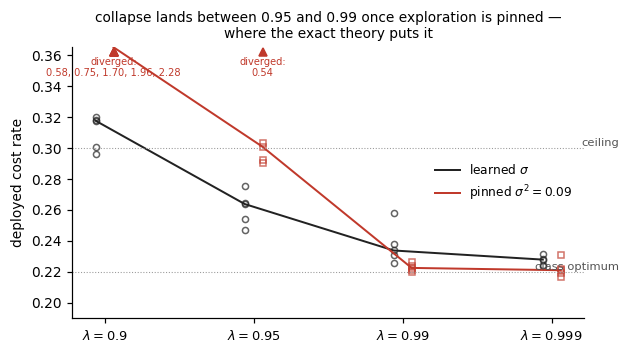

In [8]:
# figure: the lambda-sweep plateaus — learned sigma vs pinned sigma
rrr = [json.loads(l) for l in open("../results/results_gleam_rerun.jsonl")]
lams = [0.9, 0.95, 0.99, 0.999]
KEY1 = {0.9: "e1_ml_lam0.9", 0.95: "e1_lamsweep_0.95",
        0.99: "e1_lamsweep_0.99", 0.999: "e1_lamsweep_0.999"}
KEY2 = {l: f"r_fixsig_lam{l}" for l in lams}
def seedJ(rs, key): return [r["J_deploy"] for r in rs if r["exp"] == key]
fig, ax = plt.subplots(figsize=(6.0, 3.2))
x = np.arange(len(lams)); YTOP = 0.365
for xs, l in zip(x, lams):
    ax.plot([xs-0.06]*5, seedJ(ext, KEY1[l]), "o", ms=4, mfc="none", mec=INK, mew=1, alpha=0.7)
ax.plot(x-0.06, [np.median(seedJ(ext, KEY1[l])) for l in lams], "-", color=INK, lw=1.3,
        label="learned $\\sigma$")
for xs, l in zip(x, lams):
    Js_ = seedJ(rrr, KEY2[l])
    inside = [j for j in Js_ if j <= YTOP]; above = [j for j in Js_ if j > YTOP]
    ax.plot([xs+0.06]*len(inside), inside, "s", ms=4, mfc="none", mec=RED, mew=1, alpha=0.7)
    if above:   # divergent seeds: marker at axis top + true values written out, no fake position
        ax.plot([xs+0.06]*len(above), [YTOP-0.003]*len(above), "^", ms=5, color=RED)
        ax.annotate("diverged:\n" + ", ".join(f"{j:.2f}" for j in sorted(above)),
                    (xs+0.06, YTOP-0.006), fontsize=6.5, color=RED, ha="center", va="top")
med2 = [np.median([min(j, YTOP) for j in seedJ(rrr, KEY2[l])]) for l in lams]
ax.plot(x+0.06, med2, "-", color=RED, lw=1.3, label="pinned $\\sigma^2=0.09$")
for y, t in [(CEIL, "ceiling"), (Jml, "class optimum")]:
    ax.axhline(y, color=GREY, lw=0.7, ls=":"); ax.text(3.45, y+0.0015, t, fontsize=7.5, ha="right", color="#555")
ax.set_xticks(x); ax.set_xticklabels([f"$\\lambda={l}$" for l in lams], fontsize=8.5)
ax.set_ylabel("deployed cost rate"); ax.set_ylim(0.19, YTOP)
ax.legend(frameon=False, fontsize=8, loc="center right")
ax.set_title("collapse lands between 0.95 and 0.99 once exploration is pinned —\n"
             "where the exact theory puts it", fontsize=9)
plt.show()

### Results — follow-ups (i) and (iii); (ii) is §7

**(i) Fixed-exploration sweep — the transition lands where the theory puts it.** With
$\sigma^2$ pinned: $\lambda=0.95$ parks at the ceiling $r\Theta K(0)=0.300$ (median $0.3007$;
the transition region is bimodal across seeds), $\lambda=0.99$ and $0.999$ restore to the
class optimum. The collapse sits between $0.95$ and $0.99$ — exactly the interval the exact
$\lambda$-theory computes for this environment's memory time ($k_{\mathrm{eq}}\!: 17.7 \to
2.2$). Round 1's shifted transition was the exploration confound, demonstrated by controlled
experiment. ($\lambda=0.9$ at pinned $\sigma$ destabilizes — gains flip negative and $J$
diverges; quote it only as "destabilizes," see §7.)

**(iii) Batch structure — ruled out.** The numpy-matched geometry gives gain $2.9$ vs the
CleanRL-shaped $2.5$: the $\lambda=0$ magnitude gap is not batch geometry; it remains
attributable to optimizer/initialization differences and is reported as open.

## 7. Training dynamics: capture and overshoot

The per-run curves settle what single end-point numbers could not.

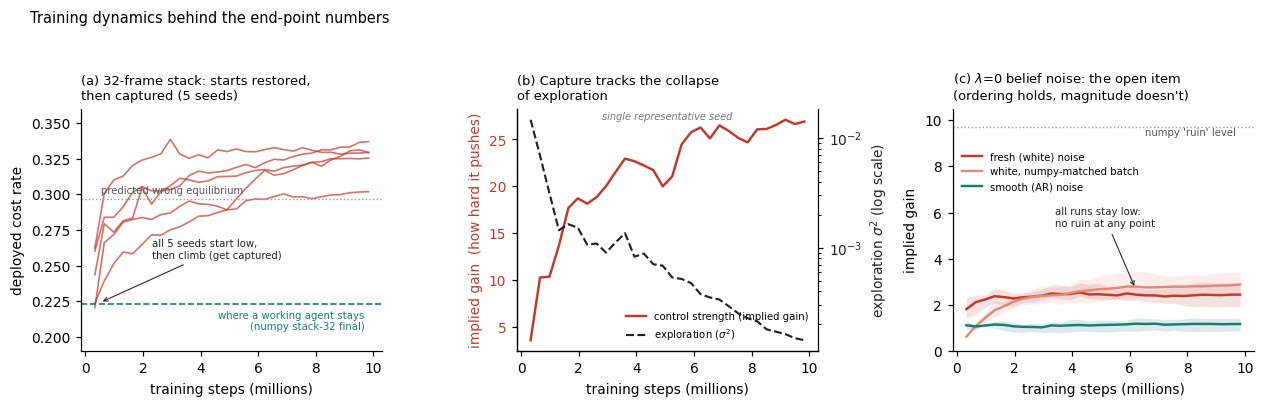

In [9]:
# FIGURE 5 (rebuilt): training dynamics, three labelled panels (a)/(b)/(c).
CUR = "../results/curves/"
J_WRONG = 0.2964
fig, axs = plt.subplots(1, 3, figsize=(11.5, 3.5)); plt.subplots_adjust(wspace=0.42)

# (a) stack32 five seeds: restored -> captured
ax = axs[0]
for s in range(1, 6):
    d = np.genfromtxt(CUR + f"curves_r_stack32_lam0.9_{s}.csv", delimiter=",", names=True)
    ax.plot(d["global_step"] / 1e6, d["J_or_return"], lw=1.1, color=RED, alpha=0.7)
ax.axhline(J_WRONG, color=GREY, ls=":", lw=0.9)
ax.axhline(0.2229, color=TEAL, ls="--", lw=1.1)
ax.text(0.55, J_WRONG + 0.004, "predicted wrong equilibrium", fontsize=6.6, ha="left", color="#555")
ax.text(9.7, 0.2229 - 0.004, "where a working agent stays\n(numpy stack-32 final)",
        fontsize=6.6, ha="right", va="top", color=TEAL)
ax.annotate("all 5 seeds start low,\nthen climb (get captured)", xy=(0.5, 0.224),
            xytext=(2.3, 0.255), fontsize=6.6, color=INK,
            arrowprops=dict(arrowstyle="->", color=INK, lw=0.7))
ax.set_ylim(0.19, 0.36); ax.set_xlabel("training steps (millions)")
ax.set_ylabel("deployed cost rate")
ax.set_title("(a) 32-frame stack: starts restored,\nthen captured (5 seeds)", fontsize=8.5, loc="left")

# (b) capture tracks exploration collapse (single seed, twin axis)
ax = axs[1]
d = np.genfromtxt(CUR + "curves_r_stack32_lam0.9_1.csv", delimiter=",", names=True)
x = d["global_step"] / 1e6
l1, = ax.plot(x, d["gain_or_actnorm"], color=RED, lw=1.6, label="control strength (implied gain)")
ax.set_ylabel("implied gain  (how hard it pushes)", color=RED); ax.tick_params(axis="y", labelcolor=RED)
ax2 = ax.twinx()
l2, = ax2.plot(x, np.exp(2 * d["logstd"]), color=INK, lw=1.4, ls="--", label="exploration ($\\sigma^2$)")
ax2.set_yscale("log"); ax2.set_ylabel("exploration $\\sigma^2$ (log scale)", color=INK)
ax2.spines["right"].set_visible(True); ax2.tick_params(axis="y", labelcolor=INK)
ax.set_xlabel("training steps (millions)")
ax.legend(handles=[l1, l2], frameon=False, fontsize=6.6, loc="lower right")
ax.text(0.5, 0.99, "single representative seed", transform=ax.transAxes,
        fontsize=6.4, style="italic", color="#777", va="top", ha="center")
ax.set_title("(b) Capture tracks the collapse\nof exploration", fontsize=8.5, loc="left")

# (c) lambda=0 belief noise: no ruin in the mirror
ax = axs[2]
for exp, c, lab in [("r_asym_white003_lam0.0", RED, "fresh (white) noise"),
                    ("r_asym_white003_lam0.0_np", "#e08a7d", "white, numpy-matched batch"),
                    ("r_asym_ar003_lam0.0", TEAL, "smooth (AR) noise")]:
    G = np.array([np.genfromtxt(CUR + f"curves_{exp}_{s}.csv", delimiter=",", names=True)["gain_or_actnorm"]
                  for s in range(1, 6)])
    gs = np.genfromtxt(CUR + f"curves_{exp}_1.csv", delimiter=",", names=True)["global_step"] / 1e6
    ax.plot(gs, G.mean(0), lw=1.6, color=c, label=lab)
    ax.fill_between(gs, G.min(0), G.max(0), color=c, alpha=0.15, lw=0)
ax.axhline(9.7, color=GREY, ls=":", lw=0.9)
ax.text(9.7, 9.35, "numpy 'ruin' level", fontsize=6.6, ha="right", color="#555")
ax.annotate("all runs stay low:\nno ruin at any point", xy=(6.2, 2.7), xytext=(3.4, 5.4),
            fontsize=6.6, color=INK, arrowprops=dict(arrowstyle="->", color=INK, lw=0.7))
ax.set_xlabel("training steps (millions)"); ax.set_ylabel("implied gain"); ax.set_ylim(0, 10.5)
ax.legend(frameon=False, fontsize=6.6, loc="upper left", bbox_to_anchor=(0.0, 0.86))
ax.set_title("(c) $\\lambda$=0 belief noise: the open item\n(ordering holds, magnitude doesn't)",
             fontsize=8.5, loc="left")
fig.suptitle("Training dynamics behind the end-point numbers", fontsize=9.5, y=1.04, x=0.02, ha="left")
plt.tight_layout(); plt.show()

**How to read this.** The training-time story behind the end-point numbers. **(a)** all five 32-frame-stack seeds *begin* near the working-agent cost (teal dashed) and then rise to the predicted wrong equilibrium (grey dotted) — the restored solution is only *metastable* and gets “captured.” **(b)** for one seed, control strength (implied gain, red, left axis) inflates exactly as exploration $\sigma^2$ (black dashed, right log axis) collapses — capture tracks the entropy collapse. **(c)** at $\lambda$=0, all three belief-noise runs stay far below the “ruin” level the numpy agent hit: the predicted *ordering* (white > AR) holds, but the *magnitude* of the damage does not reproduce — the one open empirical item.

**(a)/(b) — capture.** *Terms:* we call the healthy solution's neighborhood the **restored
basin** and the phantom equilibrium's the **phantom basin**; **capture** means a run that
starts in the first and ends in the second; restoration is **metastable** when capture is
eventually triggered by the agent's own dynamics. **Takeaway: all five stack32 seeds start
restored and are captured as their exploration collapses.** At 0.33M steps they sit at
$J=0.22$–$0.26$ (the numpy agent's final state); by 10M they are on the phantom plateau with
gains 7–33, and the capture co-times with $\sigma^2$ decaying to $\sim 2\times10^{-4}$ (panel
b). The numpy agent that stayed restored kept $50\times$ more exploration. In the theory's
terms: shrinking $\nu$ strengthens the phantom attractor (the $\chi$ law), so input memory
alone is not a reliable repair below the bootstrap-horizon condition — the horizon is the
lever that removes the attractor rather than racing it. Clean follow-up, pre-registerable:
stack32 with $\sigma^2$ pinned; prediction: no capture. (stack8, the negative control, is
worse, as predicted; one seed destabilizes outright.)

**Fixed-$\sigma$ $\lambda=0.9$ — overshoot.** With exploration pinned, every seed inflates to
gain 13–19 and then crosses the stability boundary (gains flip negative, $J$ diverges): PPO
overshoots the equilibrium instead of parking at it. The equilibrium's pull is confirmed; its
stability under PPO's step sizes is a separate question, flagged as open.

**(c) — the open item.** At $\lambda=0$, 3% *fresh* (white) belief noise never ruins the
CleanRL-shaped agent within 10M steps, in either batch geometry — while it ruined the numpy
agent (gain 9.7) by 2.6M. The predicted noise-type *ordering* (fresh $>$ smooth $>$ none)
holds throughout; the damage *magnitude* is implementation-dependent (candidates: Adam,
initialization, value clipping). Stated as such wherever this result is used.

## 8. Summary of evidence

**Established with a standard implementation, multi-seed, predictions frozen in advance:**
the false-equilibrium plateau (at the exploration-conditional ceiling); the $\lambda=1$ causal
test; the location of the $\lambda$-transition (fixed-exploration sweep); belief-critic
restoration at $\lambda=0.9$ under all noise types; the noise-type ordering at $\lambda=0$;
directional transfer on velocity-only Walker2d.

**Established in-family (single implementation; consistency checks, not estimates):**
kernel-mass invariance of the plateau, the $\chi/h$ frequency scaling, the
more-exploration–lower-equilibrium prediction, the nonlinear (cubic-drag) signature.

**New finding produced by a failed gate:** metastable restoration — memory-equipped agents
start in the restored solution and are captured by the false equilibrium as exploration
decays (§7). The reliable lever is the bootstrap horizon, not input memory.

**Open:** the magnitude (not ordering) of $\lambda=0$ belief-noise damage is
implementation-dependent.

**Provenance.** Raw rows: `../results/*.jsonl`; frozen predictions:
`../preregistration-external.md`; gates as scored: `../results/analysis_report*.txt`;
time-courses: `../results/curves/`; in-family logs: `../results/numpy_logs/`. External stack:
CleanRL (Huang et al., JMLR 2022), Gymnasium, MuJoCo (Todorov et al., 2012). Theory,
notation, and references: `formal_proofs` notebook.